Using device: cuda
Epoch [1/10], Loss: 0.7310
Epoch [2/10], Loss: 0.5170
Epoch [3/10], Loss: 0.5024
Epoch [4/10], Loss: 0.4373
Epoch [5/10], Loss: 0.4237
Epoch [6/10], Loss: 0.6052
Epoch [7/10], Loss: 0.4946
Epoch [8/10], Loss: 0.4245
Epoch [9/10], Loss: 0.4436
Epoch [10/10], Loss: 0.5334
Overall Accuracy: 0.8448
Average Accuracy: 0.8752
Kappa Score: 0.8257


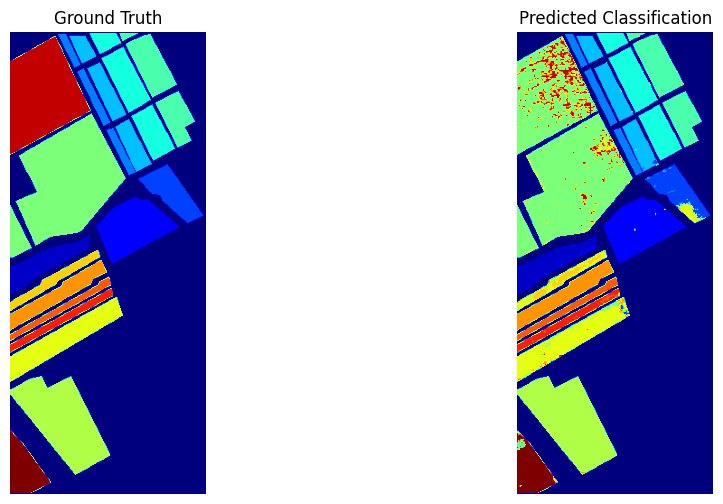

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import scipy.io as sio
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix

# Load Salinas hyperspectral data and ground truth
data_dict = sio.loadmat('./Data/salinas_corrected.mat')
gt_dict = sio.loadmat('./Data/salinas_gt.mat')

# Assume variable names in .mat files
data_cube = data_dict['salinas_corrected']  # shape: (height, width, num_bands)
gt = gt_dict['salinas_gt']                  # shape: (height, width)

# Extract pixels with valid ground truth (label > 0)
indices = np.where(gt > 0)  # tuple of (row_indices, col_indices)
X_all = data_cube[indices]  # shape: (num_samples, num_bands)
y_all = gt[indices].astype(np.int64) - 1  # convert to 0-indexed labels

num_bands = data_cube.shape[2]

# Split into training and testing sets; also store indices for later visualization
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_all, y_all, np.arange(X_all.shape[0]), test_size=0.3, random_state=42, stratify=y_all
)

# Convert arrays to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)
# Also keep the entire dataset as tensor for visualization
X_all_tensor = torch.tensor(X_all, dtype=torch.float32)
y_all_tensor = torch.tensor(y_all, dtype=torch.long)

# Create DataLoader objects
batch_size = 256
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# Define a 1D CNN model for hyperspectral image classification
class HyperspectralCNN(nn.Module):
    def __init__(self, num_bands, num_classes):
        super(HyperspectralCNN, self).__init__()
        # Each input sample is a 1D signal of length num_bands (with 1 channel)
        self.layer1 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)  # length reduced by factor 2
        )
        self.layer2 = nn.Sequential(
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)  # length reduced by factor 2
        )
        self.layer3 = nn.Sequential(
            nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)  # length reduced by factor 2
        )
        # After 3 poolings, the length becomes num_bands//8 (assumes num_bands divisible by 8)
        self.fc = nn.Sequential(
            nn.Linear(256 * (num_bands // 8), 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        # x shape: (batch_size, num_bands)
        x = x.unsqueeze(1)  # reshape to (batch_size, 1, num_bands)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = x.view(x.size(0), -1)  # flatten
        x = self.fc(x)
        return x

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

num_classes = int(y_all.max() + 1)
learning_rate = 0.001
num_epochs = 10

model = HyperspectralCNN(num_bands=num_bands, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

# Evaluate on test set
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# Compute classification metrics on test set
overall_accuracy = accuracy_score(all_targets, all_preds)
cm = confusion_matrix(all_targets, all_preds)
class_acc = cm.diagonal() / cm.sum(axis=1)
average_accuracy = class_acc.mean()
kappa = cohen_kappa_score(all_targets, all_preds)
print(f"Overall Accuracy: {overall_accuracy:.4f}")
print(f"Average Accuracy: {average_accuracy:.4f}")
print(f"Kappa Score: {kappa:.4f}")

# Generate predictions for the entire dataset for visualization
model.eval()
with torch.no_grad():
    outputs_all = model(X_all_tensor.to(device))
    _, preds_all = torch.max(outputs_all.data, 1)
preds_all = preds_all.cpu().numpy()

# Reconstruct the predicted classification image for valid pixels
pred_map = np.zeros_like(gt, dtype=np.int32)
# Since original ground truth was >0 and we subtracted 1, add 1 back for visualization
pred_map[indices] = preds_all + 1  

# Create ground truth map (convert back to 1-indexed labels)
gt_map = np.zeros_like(gt, dtype=np.int32)
gt_map[indices] = y_all + 1

# Plot the ground truth and predicted classification images
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(gt_map, cmap='jet')
plt.title("Ground Truth")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(pred_map, cmap='jet')
plt.title("Predicted Classification")
plt.axis('off')
plt.show()


# 1D CNN Using Mixed Precision

# HanChuan DataSet

Using device: cuda
Epoch [1/10], Loss: 0.7997
Epoch [2/10], Loss: 0.5830
Epoch [3/10], Loss: 0.5151
Epoch [4/10], Loss: 0.4767
Epoch [5/10], Loss: 0.4513
Epoch [6/10], Loss: 0.4287
Epoch [7/10], Loss: 0.4117
Epoch [8/10], Loss: 0.3977
Epoch [9/10], Loss: 0.3865
Epoch [10/10], Loss: 0.3747
Overall Accuracy: 0.8940
Average Accuracy: 0.7557
Kappa Score: 0.8755


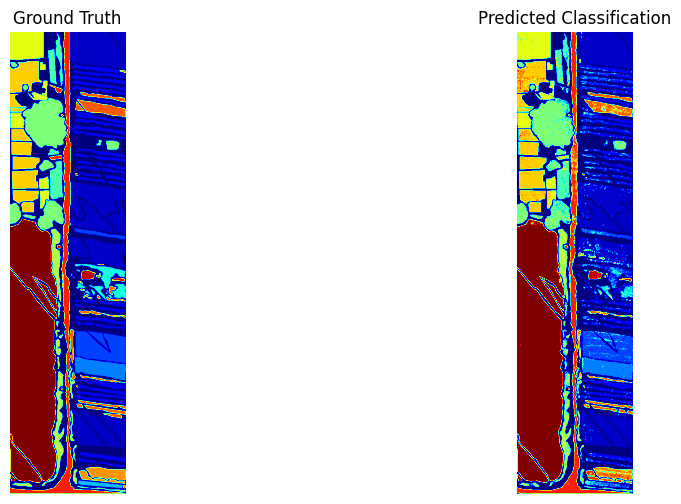

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import scipy.io as sio
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix
from torch.cuda.amp import autocast, GradScaler

# Load Salinas hyperspectral data and ground truth
data_dict = sio.loadmat('./Data/WHU_Hi_HanChuan.mat')
gt_dict = sio.loadmat('./Data/WHU_Hi_HanChuan_gt.mat')

# Assume variable names in .mat files
data_cube = data_dict['WHU_Hi_HanChuan']  # shape: (height, width, num_bands)
gt = gt_dict['WHU_Hi_HanChuan_gt']         # shape: (height, width)

# Extract pixels with valid ground truth (label > 0)
indices = np.where(gt > 0)  # tuple of (row_indices, col_indices)
X_all = data_cube[indices]  # shape: (num_samples, num_bands)
y_all = gt[indices].astype(np.int64) - 1  # convert to 0-indexed labels

num_bands = data_cube.shape[2]

# Split into training and testing sets; also store indices for later visualization
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_all, y_all, np.arange(X_all.shape[0]), test_size=0.3, random_state=42, stratify=y_all
)

# Convert arrays to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)
# Also keep the entire dataset as tensor for visualization
X_all_tensor = torch.tensor(X_all, dtype=torch.float32)
y_all_tensor = torch.tensor(y_all, dtype=torch.long)

# Create DataLoader objects
batch_size = 64
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# Define a 1D CNN model for hyperspectral image classification
class HyperspectralCNN(nn.Module):
    def __init__(self, num_bands, num_classes):
        super(HyperspectralCNN, self).__init__()
        # Each input sample is a 1D signal of length num_bands (with 1 channel)
        self.layer1 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)  # length reduced by factor 2
        )
        self.layer2 = nn.Sequential(
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)  # length reduced by factor 2
        )
        self.layer3 = nn.Sequential(
            nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)  # length reduced by factor 2
        )
        # After 3 poolings, the length becomes num_bands//8 (assumes num_bands divisible by 8)
        self.fc = nn.Sequential(
            nn.Linear(256 * (num_bands // 8), 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        # x shape: (batch_size, num_bands)
        x = x.unsqueeze(1)  # reshape to (batch_size, 1, num_bands)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = x.view(x.size(0), -1)  # flatten
        x = self.fc(x)
        return x

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

num_classes = int(y_all.max() + 1)
learning_rate = 0.001
num_epochs = 10

model = HyperspectralCNN(num_bands=num_bands, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Initialize the GradScaler for mixed precision training
scaler = GradScaler()

# Training loop with mixed precision
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        # Forward pass under autocast for mixed precision
        with autocast():
            outputs = model(inputs)
            loss = criterion(outputs, targets)
        
        # Scale the loss and backpropagate
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

# Evaluation on test set with mixed precision
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        with autocast():
            outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# Compute classification metrics on test set
overall_accuracy = accuracy_score(all_targets, all_preds)
cm = confusion_matrix(all_targets, all_preds)
class_acc = cm.diagonal() / cm.sum(axis=1)
average_accuracy = class_acc.mean()
kappa = cohen_kappa_score(all_targets, all_preds)
print(f"Overall Accuracy: {overall_accuracy:.4f}")
print(f"Average Accuracy: {average_accuracy:.4f}")
print(f"Kappa Score: {kappa:.4f}")

# Generate predictions for the entire dataset for visualization using mixed precision
# Define a small inference batch size that fits into GPU memory
inference_batch_size = 2  # You can adjust this further if needed
preds_all = []

model.eval()
with torch.no_grad():
    for i in range(0, X_all_tensor.size(0), inference_batch_size):
        # Slice the tensor into a mini-batch and move it to the device
        batch = X_all_tensor[i:i+inference_batch_size].to(device)
        with autocast():
            outputs = model(batch)
        # Get the predictions for the mini-batch
        _, predicted = torch.max(outputs, 1)
        preds_all.append(predicted.cpu())
        # Optionally clear cache to reduce fragmentation
        torch.cuda.empty_cache()

# Concatenate the predictions from all mini-batches
preds_all = torch.cat(preds_all, dim=0).numpy()

# Reconstruct the predicted classification image for valid pixels
pred_map = np.zeros_like(gt, dtype=np.int32)
# Since original ground truth was >0 and we subtracted 1, add 1 back for visualization
pred_map[indices] = preds_all + 1  

# Create ground truth map (convert back to 1-indexed labels)
gt_map = np.zeros_like(gt, dtype=np.int32)
gt_map[indices] = y_all + 1

# Plot the ground truth and predicted classification images
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(gt_map, cmap='jet')
plt.title("Ground Truth")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(pred_map, cmap='jet')
plt.title("Predicted Classification")
plt.axis('off')
plt.show()


In [2]:
# Evaluation on Test Set with Mixed Precision
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        with autocast():
            outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# Compute overall metrics
overall_accuracy = accuracy_score(all_targets, all_preds)
cm = confusion_matrix(all_targets, all_preds)
# Compute class-wise accuracy: diagonal elements divided by row sums of confusion matrix
class_acc = cm.diagonal() / cm.sum(axis=1)
average_accuracy = class_acc.mean()
kappa = cohen_kappa_score(all_targets, all_preds)

print(f"Overall Accuracy: {overall_accuracy:.4f}")
print(f"Average Accuracy: {average_accuracy:.4f}")
print(f"Kappa Score: {kappa:.4f}")

# Print class-wise accuracies
for i, acc in enumerate(class_acc):
    print(f"Accuracy for class {i}: {acc:.4f}")


Overall Accuracy: 0.8940
Average Accuracy: 0.7557
Kappa Score: 0.8755
Accuracy for class 0: 0.9690
Accuracy for class 1: 0.7940
Accuracy for class 2: 0.8970
Accuracy for class 3: 0.9178
Accuracy for class 4: 0.3083
Accuracy for class 5: 0.3382
Accuracy for class 6: 0.8436
Accuracy for class 7: 0.8689
Accuracy for class 8: 0.8078
Accuracy for class 9: 0.9426
Accuracy for class 10: 0.9464
Accuracy for class 11: 0.3569
Accuracy for class 12: 0.6523
Accuracy for class 13: 0.8486
Accuracy for class 14: 0.6070
Accuracy for class 15: 0.9933


# HongHu Dataset

Using device: cuda
Epoch [1/100], Loss: 0.8009
Epoch [2/100], Loss: 0.6418
Epoch [3/100], Loss: 0.5950
Epoch [4/100], Loss: 0.5675
Epoch [5/100], Loss: 0.5458
Epoch [6/100], Loss: 0.5314
Epoch [7/100], Loss: 0.5176
Epoch [8/100], Loss: 0.5055
Epoch [9/100], Loss: 0.4936
Epoch [10/100], Loss: 0.4858
Epoch [11/100], Loss: 0.4759
Epoch [12/100], Loss: 0.4701
Epoch [13/100], Loss: 0.4627
Epoch [14/100], Loss: 0.4596
Epoch [15/100], Loss: 0.4526
Epoch [16/100], Loss: 0.4442
Epoch [17/100], Loss: 0.4396
Epoch [18/100], Loss: 0.4371
Epoch [19/100], Loss: 0.4297
Epoch [20/100], Loss: 0.4257
Epoch [21/100], Loss: 0.4216
Epoch [22/100], Loss: 0.4169
Epoch [23/100], Loss: 0.4118
Epoch [24/100], Loss: 0.4086
Epoch [25/100], Loss: 0.4032
Epoch [26/100], Loss: 0.4006
Epoch [27/100], Loss: 0.3976
Epoch [28/100], Loss: 0.3921
Epoch [29/100], Loss: 0.3883
Epoch [30/100], Loss: 0.3877
Epoch [31/100], Loss: 0.3833
Epoch [32/100], Loss: 0.3797
Epoch [33/100], Loss: 0.3787
Epoch [34/100], Loss: 0.3747
Epoc

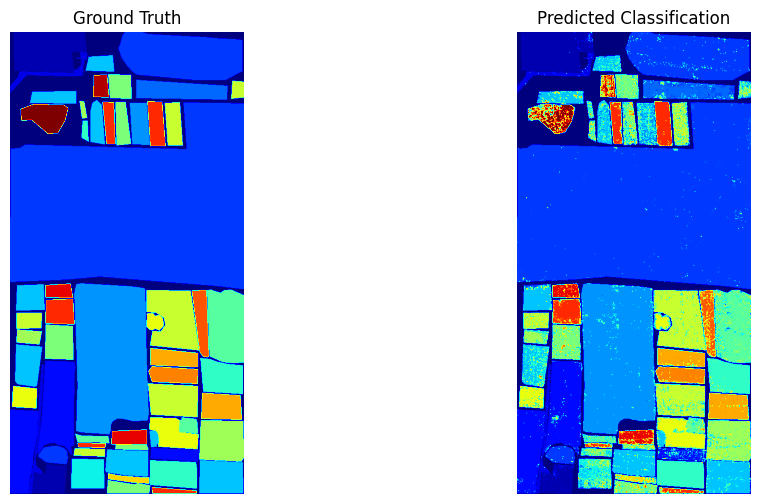

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import scipy.io as sio
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix
from torch.cuda.amp import autocast, GradScaler

# Load Salinas hyperspectral data and ground truth
data_dict = sio.loadmat('./Data/WHU_Hi_HongHu.mat')
gt_dict = sio.loadmat('./Data/WHU_Hi_HongHu_gt.mat')

# Assume variable names in .mat files
data_cube = data_dict['WHU_Hi_HongHu']  # shape: (height, width, num_bands)
gt = gt_dict['WHU_Hi_HongHu_gt']         # shape: (height, width)

# Extract pixels with valid ground truth (label > 0)
indices = np.where(gt > 0)  # tuple of (row_indices, col_indices)
X_all = data_cube[indices]  # shape: (num_samples, num_bands)
y_all = gt[indices].astype(np.int64) - 1  # convert to 0-indexed labels

num_bands = data_cube.shape[2]

# Split into training and testing sets; also store indices for later visualization
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_all, y_all, np.arange(X_all.shape[0]), test_size=0.3, random_state=42, stratify=y_all
)

# Convert arrays to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)
# Also keep the entire dataset as tensor for visualization
X_all_tensor = torch.tensor(X_all, dtype=torch.float32)
y_all_tensor = torch.tensor(y_all, dtype=torch.long)

# Create DataLoader objects
batch_size = 64
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# Define a 1D CNN model for hyperspectral image classification
class HyperspectralCNN(nn.Module):
    def __init__(self, num_bands, num_classes):
        super(HyperspectralCNN, self).__init__()
        # Each input sample is a 1D signal of length num_bands (with 1 channel)
        self.layer1 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)  # length reduced by factor 2
        )
        self.layer2 = nn.Sequential(
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)  # length reduced by factor 2
        )
        self.layer3 = nn.Sequential(
            nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)  # length reduced by factor 2
        )
        # After 3 poolings, the length becomes num_bands//8 (assumes num_bands divisible by 8)
        self.fc = nn.Sequential(
            nn.Linear(256 * (num_bands // 8), 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        # x shape: (batch_size, num_bands)
        x = x.unsqueeze(1)  # reshape to (batch_size, 1, num_bands)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = x.view(x.size(0), -1)  # flatten
        x = self.fc(x)
        return x

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

num_classes = int(y_all.max() + 1)
learning_rate = 0.001
num_epochs = 100

model = HyperspectralCNN(num_bands=num_bands, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Initialize the GradScaler for mixed precision training
scaler = GradScaler()

# Training loop with mixed precision
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        # Forward pass under autocast for mixed precision
        with autocast():
            outputs = model(inputs)
            loss = criterion(outputs, targets)
        
        # Scale the loss and backpropagate
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

# Evaluation on test set with mixed precision
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        with autocast():
            outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# Compute classification metrics on test set
overall_accuracy = accuracy_score(all_targets, all_preds)
cm = confusion_matrix(all_targets, all_preds)
class_acc = cm.diagonal() / cm.sum(axis=1)
average_accuracy = class_acc.mean()
kappa = cohen_kappa_score(all_targets, all_preds)
print(f"Overall Accuracy: {overall_accuracy:.4f}")
print(f"Average Accuracy: {average_accuracy:.4f}")
print(f"Kappa Score: {kappa:.4f}")

# Generate predictions for the entire dataset for visualization using mixed precision
# Define a small inference batch size that fits into GPU memory
inference_batch_size = 2  # You can adjust this further if needed
preds_all = []

model.eval()
with torch.no_grad():
    for i in range(0, X_all_tensor.size(0), inference_batch_size):
        # Slice the tensor into a mini-batch and move it to the device
        batch = X_all_tensor[i:i+inference_batch_size].to(device)
        with autocast():
            outputs = model(batch)
        # Get the predictions for the mini-batch
        _, predicted = torch.max(outputs, 1)
        preds_all.append(predicted.cpu())
        # Optionally clear cache to reduce fragmentation
        torch.cuda.empty_cache()

# Concatenate the predictions from all mini-batches
preds_all = torch.cat(preds_all, dim=0).numpy()

# Reconstruct the predicted classification image for valid pixels
pred_map = np.zeros_like(gt, dtype=np.int32)
# Since original ground truth was >0 and we subtracted 1, add 1 back for visualization
pred_map[indices] = preds_all + 1  

# Create ground truth map (convert back to 1-indexed labels)
gt_map = np.zeros_like(gt, dtype=np.int32)
gt_map[indices] = y_all + 1

# Plot the ground truth and predicted classification images
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(gt_map, cmap='jet')
plt.title("Ground Truth")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(pred_map, cmap='jet')
plt.title("Predicted Classification")
plt.axis('off')
plt.show()


In [4]:
# Evaluation on Test Set with Mixed Precision
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        with autocast():
            outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# Compute overall metrics
overall_accuracy = accuracy_score(all_targets, all_preds)
cm = confusion_matrix(all_targets, all_preds)
# Compute class-wise accuracy: diagonal elements divided by row sums of confusion matrix
class_acc = cm.diagonal() / cm.sum(axis=1)
average_accuracy = class_acc.mean()
kappa = cohen_kappa_score(all_targets, all_preds)

print(f"Overall Accuracy: {overall_accuracy:.4f}")
print(f"Average Accuracy: {average_accuracy:.4f}")
print(f"Kappa Score: {kappa:.4f}")

# Print class-wise accuracies
for i, acc in enumerate(class_acc):
    print(f"Accuracy for class {i}: {acc:.4f}")


Overall Accuracy: 0.8992
Average Accuracy: 0.7744
Kappa Score: 0.8721
Accuracy for class 0: 0.9563
Accuracy for class 1: 0.8349
Accuracy for class 2: 0.9216
Accuracy for class 3: 0.9850
Accuracy for class 4: 0.7062
Accuracy for class 5: 0.9467
Accuracy for class 6: 0.8493
Accuracy for class 7: 0.4095
Accuracy for class 8: 0.9677
Accuracy for class 9: 0.7176
Accuracy for class 10: 0.6628
Accuracy for class 11: 0.6389
Accuracy for class 12: 0.8024
Accuracy for class 13: 0.8015
Accuracy for class 14: 0.7010
Accuracy for class 15: 0.9073
Accuracy for class 16: 0.7896
Accuracy for class 17: 0.7254
Accuracy for class 18: 0.8699
Accuracy for class 19: 0.7763
Accuracy for class 20: 0.4548
Accuracy for class 21: 0.6122


# LongKou Dataset

Using device: cuda
Epoch [1/1], Loss: 0.3102
Overall Accuracy: 0.9381
Average Accuracy: 0.7870
Kappa Score: 0.9182


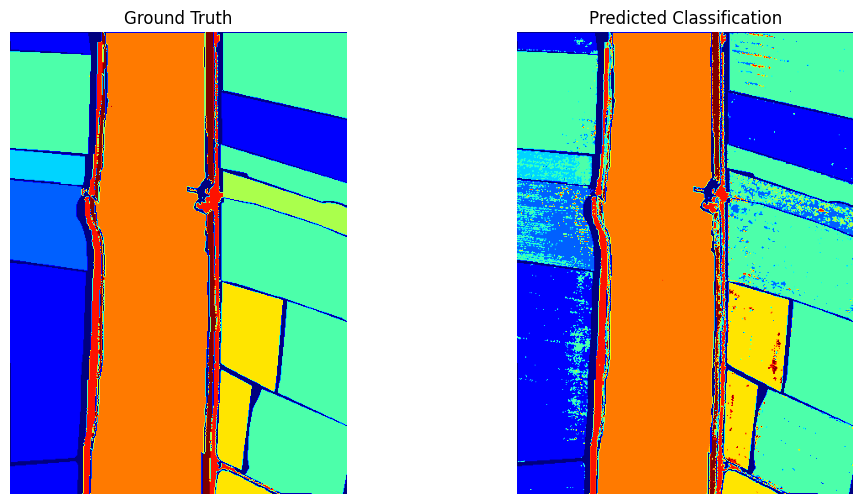

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import scipy.io as sio
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix
from torch.cuda.amp import autocast, GradScaler

# Load Salinas hyperspectral data and ground truth
data_dict = sio.loadmat('./Data/WHU_Hi_LongKou.mat')
gt_dict = sio.loadmat('./Data/WHU_Hi_LongKou_gt.mat')

# Assume variable names in .mat files
data_cube = data_dict['WHU_Hi_LongKou']  # shape: (height, width, num_bands)
gt = gt_dict['WHU_Hi_LongKou_gt']         # shape: (height, width)

# Extract pixels with valid ground truth (label > 0)
indices = np.where(gt > 0)  # tuple of (row_indices, col_indices)
X_all = data_cube[indices]  # shape: (num_samples, num_bands)
y_all = gt[indices].astype(np.int64) - 1  # convert to 0-indexed labels

num_bands = data_cube.shape[2]

# Split into training and testing sets; also store indices for later visualization
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_all, y_all, np.arange(X_all.shape[0]), test_size=0.3, random_state=42, stratify=y_all
)

# Convert arrays to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)
# Also keep the entire dataset as tensor for visualization
X_all_tensor = torch.tensor(X_all, dtype=torch.float32)
y_all_tensor = torch.tensor(y_all, dtype=torch.long)

# Create DataLoader objects
batch_size = 64
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# Define a 1D CNN model for hyperspectral image classification
class HyperspectralCNN(nn.Module):
    def __init__(self, num_bands, num_classes):
        super(HyperspectralCNN, self).__init__()
        # Each input sample is a 1D signal of length num_bands (with 1 channel)
        self.layer1 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)  # length reduced by factor 2
        )
        self.layer2 = nn.Sequential(
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)  # length reduced by factor 2
        )
        self.layer3 = nn.Sequential(
            nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)  # length reduced by factor 2
        )
        # After 3 poolings, the length becomes num_bands//8 (assumes num_bands divisible by 8)
        self.fc = nn.Sequential(
            nn.Linear(256 * (num_bands // 8), 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        # x shape: (batch_size, num_bands)
        x = x.unsqueeze(1)  # reshape to (batch_size, 1, num_bands)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = x.view(x.size(0), -1)  # flatten
        x = self.fc(x)
        return x

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

num_classes = int(y_all.max() + 1)
learning_rate = 0.001
num_epochs = 1

model = HyperspectralCNN(num_bands=num_bands, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Initialize the GradScaler for mixed precision training
scaler = GradScaler()

# Training loop with mixed precision
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        # Forward pass under autocast for mixed precision
        with autocast():
            outputs = model(inputs)
            loss = criterion(outputs, targets)
        
        # Scale the loss and backpropagate
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

# Evaluation on test set with mixed precision
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        with autocast():
            outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# Compute classification metrics on test set
overall_accuracy = accuracy_score(all_targets, all_preds)
cm = confusion_matrix(all_targets, all_preds)
class_acc = cm.diagonal() / cm.sum(axis=1)
average_accuracy = class_acc.mean()
kappa = cohen_kappa_score(all_targets, all_preds)
print(f"Overall Accuracy: {overall_accuracy:.4f}")
print(f"Average Accuracy: {average_accuracy:.4f}")
print(f"Kappa Score: {kappa:.4f}")

# Generate predictions for the entire dataset for visualization using mixed precision
# Define a small inference batch size that fits into GPU memory
inference_batch_size = 2  # You can adjust this further if needed
preds_all = []

model.eval()
with torch.no_grad():
    for i in range(0, X_all_tensor.size(0), inference_batch_size):
        # Slice the tensor into a mini-batch and move it to the device
        batch = X_all_tensor[i:i+inference_batch_size].to(device)
        with autocast():
            outputs = model(batch)
        # Get the predictions for the mini-batch
        _, predicted = torch.max(outputs, 1)
        preds_all.append(predicted.cpu())
        # Optionally clear cache to reduce fragmentation
        torch.cuda.empty_cache()

# Concatenate the predictions from all mini-batches
preds_all = torch.cat(preds_all, dim=0).numpy()

# Reconstruct the predicted classification image for valid pixels
pred_map = np.zeros_like(gt, dtype=np.int32)
# Since original ground truth was >0 and we subtracted 1, add 1 back for visualization
pred_map[indices] = preds_all + 1  

# Create ground truth map (convert back to 1-indexed labels)
gt_map = np.zeros_like(gt, dtype=np.int32)
gt_map[indices] = y_all + 1

# Plot the ground truth and predicted classification images
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(gt_map, cmap='jet')
plt.title("Ground Truth")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(pred_map, cmap='jet')
plt.title("Predicted Classification")
plt.axis('off')
plt.show()


In [6]:
# Evaluation on Test Set with Mixed Precision
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        with autocast():
            outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# Compute overall metrics
overall_accuracy = accuracy_score(all_targets, all_preds)
cm = confusion_matrix(all_targets, all_preds)
# Compute class-wise accuracy: diagonal elements divided by row sums of confusion matrix
class_acc = cm.diagonal() / cm.sum(axis=1)
average_accuracy = class_acc.mean()
kappa = cohen_kappa_score(all_targets, all_preds)

print(f"Overall Accuracy: {overall_accuracy:.4f}")
print(f"Average Accuracy: {average_accuracy:.4f}")
print(f"Kappa Score: {kappa:.4f}")

# Print class-wise accuracies
for i, acc in enumerate(class_acc):
    print(f"Accuracy for class {i}: {acc:.4f}")


Overall Accuracy: 0.9381
Average Accuracy: 0.7870
Kappa Score: 0.9182
Accuracy for class 0: 0.9595
Accuracy for class 1: 0.7635
Accuracy for class 2: 0.6568
Accuracy for class 3: 0.9711
Accuracy for class 4: 0.2884
Accuracy for class 5: 0.9643
Accuracy for class 6: 0.9991
Accuracy for class 7: 0.8662
Accuracy for class 8: 0.6144


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import scipy.io as sio
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix
from torch.cuda.amp import autocast, GradScaler

# Load Salinas hyperspectral data and ground truth
data_dict = sio.loadmat('./Data/WHU_Hi_HanChuan.mat')
gt_dict = sio.loadmat('./Data/WHU_Hi_HanChuan_gt.mat')

# Assume variable names in .mat files
data_cube = data_dict['WHU_Hi_HanChuan']  # shape: (height, width, num_bands)
gt = gt_dict['WHU_Hi_HanChuan_gt']         # shape: (height, width)

# Extract pixels with valid ground truth (label > 0)
indices = np.where(gt > 0)  # tuple of (row_indices, col_indices)
X_all = data_cube[indices]  # shape: (num_samples, num_bands)
y_all = gt[indices].astype(np.int64) - 1  # convert to 0-indexed labels

num_bands = data_cube.shape[2]

# Split into training and testing sets; also store indices for later visualization
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_all, y_all, np.arange(X_all.shape[0]), test_size=0.3, random_state=42, stratify=y_all
)

# Convert arrays to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)
# Also keep the entire dataset as tensor for visualization
X_all_tensor = torch.tensor(X_all, dtype=torch.float32)
y_all_tensor = torch.tensor(y_all, dtype=torch.long)

# Create DataLoader objects
batch_size = 64
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)



class MyModel(nn.Module):
    def __init__(self, S, L, output_units):
        """
        S: Spatial dimension (height and width)
        L: Number of spectral bands (depth)
        output_units: Number of output classes
        """
        super(MyModel, self).__init__()
        # In Keras, the input is defined as Input((S, S, L, 1))
        # For PyTorch, we use shape: (batch, channels, L, S, S), where channels = 1.
        # --- 3D Convolutional Layers ---
        # Note: Keras kernel_size order is (height, width, depth) with channels last.
        # For PyTorch Conv3d (channels first), kernel_size is in (depth, height, width) order.
        # Therefore, we convert:
        #   Conv3D(filters=8, kernel_size=(3,3,7), activation='relu')
        # becomes:
        #   nn.Conv3d(in_channels=1, out_channels=8, kernel_size=(7, 3, 3), padding=(3,1,1))
        self.conv3d_1 = nn.Sequential(
            nn.Conv3d(1, 8, kernel_size=(7, 3, 3), padding=(3, 1, 1)),
            nn.ReLU()
        )
        self.conv3d_2 = nn.Sequential(
            nn.Conv3d(8, 16, kernel_size=(5, 3, 3), padding=(2, 1, 1)),
            nn.ReLU()
        )
        self.conv3d_3 = nn.Sequential(
            nn.Conv3d(16, 32, kernel_size=(3, 3, 3), padding=1),
            nn.ReLU()
        )
        # After conv3d_3, the output shape is (batch, 32, L, S, S)
        # In the Keras code, they reshape the tensor from shape
        # (H, W, D, C) to (H, W, D * C). In our case, we combine the channel and depth dimensions.
        # Therefore, we reshape from (batch, 32, L, S, S) to (batch, 32 * L, S, S).
        
        # --- 2D Convolutional Layer ---
        # Keras: Conv2D(filters=64, kernel_size=(3,3), activation='relu')
        # PyTorch: Use nn.Conv2d with kernel_size=3 and appropriate padding.
        self.conv2d = nn.Sequential(
            nn.Conv2d(32 * L, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )
        
        # --- Fully Connected Layers ---
        # After the 2D conv, the output shape is assumed to be (batch, 64, S, S)
        # Flattened feature size = 64 * S * S
        self.fc1 = nn.Sequential(
            nn.Linear(64 * S * S, 256),
            nn.ReLU(),
            nn.Dropout(0.4)
        )
        self.fc2 = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4)
        )
        # Output layer. In PyTorch, if using CrossEntropyLoss, do not apply softmax.
        self.out = nn.Linear(128, output_units)
        
    def forward(self, x):
        # x shape: (batch, 1, L, S, S)
        x = self.conv3d_1(x)
        x = self.conv3d_2(x)
        x = self.conv3d_3(x)  # Now x shape: (batch, 32, L, S, S)
        batch_size, channels, depth, height, width = x.shape
        # Reshape: combine the channels and depth dimensions.
        x = x.view(batch_size, channels * depth, height, width)  # New shape: (batch, 32 * L, S, S)
        x = self.conv2d(x)  # Shape: (batch, 64, S, S)
        x = torch.flatten(x, 1)  # Flatten all dimensions except batch: (batch, 64 * S * S)
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.out(x)
        return x

# Example usage:
if __name__ == "__main__":
    # Assume S, L, and output_units are defined. For example:
    S = 32        # spatial dimensions (height and width)
    L = 50        # number of spectral bands
    output_units = 10  # number of classes
    model = MyModel(S, L, output_units)
    
    # Create a dummy input tensor with shape (batch, 1, L, S, S)
    dummy_input = torch.randn(8, 1, L, S, S)
    output = model(dummy_input)
    print("Output shape:", output.shape)  # Expected: (8, output_units)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

num_classes = int(y_all.max() + 1)
learning_rate = 0.001
num_epochs = 10

model = MyModel( num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Initialize the GradScaler for mixed precision training
scaler = GradScaler()

# Training loop with mixed precision
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        # Forward pass under autocast for mixed precision
        with autocast():
            outputs = model(inputs)
            loss = criterion(outputs, targets)
        
        # Scale the loss and backpropagate
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

# Evaluation on test set with mixed precision
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        with autocast():
            outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# Compute classification metrics on test set
overall_accuracy = accuracy_score(all_targets, all_preds)
cm = confusion_matrix(all_targets, all_preds)
class_acc = cm.diagonal() / cm.sum(axis=1)
average_accuracy = class_acc.mean()
kappa = cohen_kappa_score(all_targets, all_preds)
print(f"Overall Accuracy: {overall_accuracy:.4f}")
print(f"Average Accuracy: {average_accuracy:.4f}")
print(f"Kappa Score: {kappa:.4f}")

# Generate predictions for the entire dataset for visualization using mixed precision
# Define a small inference batch size that fits into GPU memory
inference_batch_size = 2  # You can adjust this further if needed
preds_all = []

model.eval()
with torch.no_grad():
    for i in range(0, X_all_tensor.size(0), inference_batch_size):
        # Slice the tensor into a mini-batch and move it to the device
        batch = X_all_tensor[i:i+inference_batch_size].to(device)
        with autocast():
            outputs = model(batch)
        # Get the predictions for the mini-batch
        _, predicted = torch.max(outputs, 1)
        preds_all.append(predicted.cpu())
        # Optionally clear cache to reduce fragmentation
        torch.cuda.empty_cache()

# Concatenate the predictions from all mini-batches
preds_all = torch.cat(preds_all, dim=0).numpy()

# Reconstruct the predicted classification image for valid pixels
pred_map = np.zeros_like(gt, dtype=np.int32)
# Since original ground truth was >0 and we subtracted 1, add 1 back for visualization
pred_map[indices] = preds_all + 1  

# Create ground truth map (convert back to 1-indexed labels)
gt_map = np.zeros_like(gt, dtype=np.int32)
gt_map[indices] = y_all + 1

# Plot the ground truth and predicted classification images
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(gt_map, cmap='jet')
plt.title("Ground Truth")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(pred_map, cmap='jet')
plt.title("Predicted Classification")
plt.axis('off')
plt.show()


Output shape: torch.Size([8, 10])
Using device: cuda


TypeError: __init__() got an unexpected keyword argument 'num_classes'

In [ ]:
num_bands

274